In [1]:
import mcmr

/home/azma/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
x_world, y_world = 64, 64

x_grid = []
y_grid = []
for i in range(8, 64, 8):
    x_grid.append(i)
    y_grid.append(i)

material_matrix = [["Fe"] * 8 for _ in range(8)]

sources = [[0] * 8 for _ in range(8)]

In [3]:
world = mcmr.World(
    x_world=x_world, y_world=y_world,
    x_grid=x_grid, y_grid=y_grid,
    material_matrix=material_matrix,
    sources=sources,
    bc_top="reflective",
    bc_bot="reflective",
    bc_left="reflective",
    bc_right="reflective",
)

In [4]:
world.add_circles(
    radius_matrix=[[2.5] * 8 for _ in range(8)],
    material_matrix=[["C"] * 8 for _ in range(8)],
    source_matrix=[[1] * 8 for _ in range(8)],
)

In [5]:
world.export("mcmr_world.xml")

'mcmr_world.xml'

In [6]:
sim = world.run(N=1000, max_save=10)

              MCMR Simulation Engine               
 Total Particle   : 1000
running...
Progress: [1000/1000] (100%)
 Simulation End in 3.2055 seconds.



In [7]:
sim.export_xml("manual_result.xml")

In [8]:
t = sim.get_tally()
print(t.absorp_by_material)

{'C': 5, 'Fe': 995}


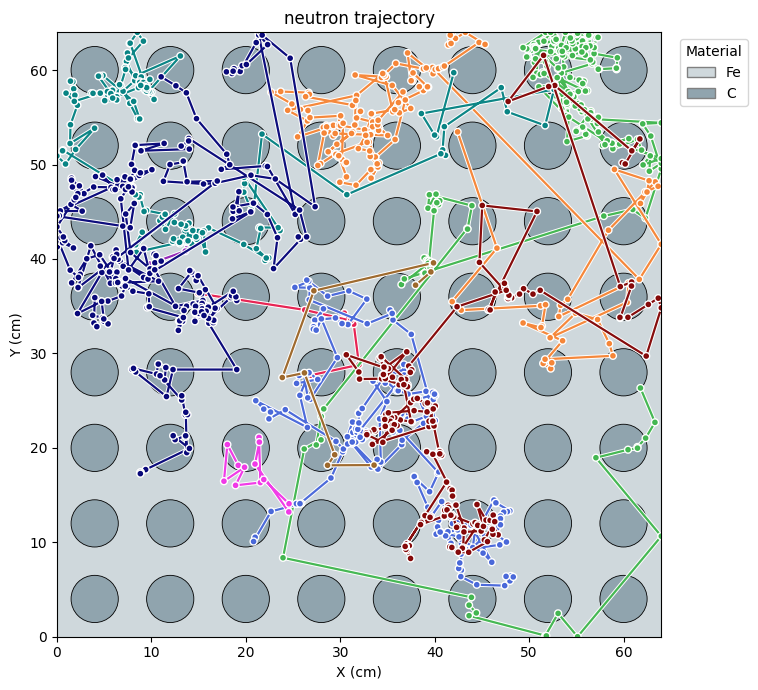

In [9]:
plotter = mcmr.ResultsPlotter("manual_result.xml")
plotter.plot_trajectories(world_xml="mcmr_world.xml")